In [ ]:
import pandas as pd

df = pd.read_csv('/content/raw_transactions.csv')

In [ ]:
display(df.head())

,customer_id,order_date,total_amount
0,1,2023-03-12,475.603582
1,1,2022-04-17,390.947045
2,1,2022-01-21,82.229227
3,1,2023-04-12,54.487583
4,1,2023-04-04,433.757192


In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

rfm_recency = df.groupby('customer_id')['order_date'].max().reset_index()
rfm_recency.columns = ['customer_id', 'last_order_date']
rfm_recency['Recency'] = (snapshot_date - rfm_recency['last_order_date']).dt.days

display(rfm_recency.head())

,customer_id,last_order_date,Recency
0,1,2023-04-12,263
1,2,2023-01-21,344
2,3,2023-07-15,169
3,4,2023-10-09,83
4,5,2023-07-16,168


In [ ]:
rfm_frequency = df.groupby('customer_id').size().reset_index(name='Frequency')

display(rfm_frequency.head())

,customer_id,Frequency
0,1,7
1,2,2
2,3,5
3,4,3
4,5,7


In [ ]:
rfm_monetary = df.groupby('customer_id')['total_amount'].sum().reset_index()
rfm_monetary.columns = ['customer_id', 'Monetary']

display(rfm_monetary.head())

,customer_id,Monetary
0,1,1527.933029
1,2,512.062466
2,3,989.919631
3,4,609.101684
4,5,2031.191786


In [ ]:
rfm_df = rfm_recency.merge(rfm_frequency, on='customer_id')
rfm_df = rfm_df.merge(rfm_monetary, on='customer_id')

display(rfm_df.head())

,customer_id,last_order_date,Recency,Frequency,Monetary
0,1,2023-04-12,263,7,1527.933029
1,2,2023-01-21,344,2,512.062466
2,3,2023-07-15,169,5,989.919631
3,4,2023-10-09,83,3,609.101684
4,5,2023-07-16,168,7,2031.191786


In [ ]:
# Tentukan kuartil untuk setiap metrik
# Untuk Recency, kita balik urutan (skor lebih tinggi untuk R_score_lebih rendah = lebih baru)
rfm_df['R_score'] = pd.qcut(rfm_df['Recency'], q=4, labels=[4, 3, 2, 1], duplicates='drop')
rfm_df['F_score'] = pd.qcut(rfm_df['Frequency'], q=4, labels=[1, 2, 3, 4], duplicates='drop')
rfm_df['M_score'] = pd.qcut(rfm_df['Monetary'], q=4, labels=[1, 2, 3, 4], duplicates='drop')

# Gabungkan skor untuk membuat segmen RFM
rfm_df['RFM_Segment'] = rfm_df['R_score'].astype(str) + rfm_df['F_score'].astype(str) + rfm_df['M_score'].astype(str)

display(rfm_df.head())

,customer_id,last_order_date,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Segment
0,1,2023-04-12,263,7,1527.933029,1,3,3,133
1,2,2023-01-21,344,2,512.062466,1,1,1,111
2,3,2023-07-15,169,5,989.919631,2,2,2,222
3,4,2023-10-09,83,3,609.101684,3,1,1,311
4,5,2023-07-16,168,7,2031.191786,2,3,4,234


In [ ]:
def rfm_segmentation(df):
    if df['RFM_Segment'] == '444': # Recency tinggi, Frequency tinggi, Monetary tinggi
        return 'Champions'
    elif df['R_score'] >= 3 and df['F_score'] >= 3 and df['M_score'] >= 3:
        return 'Loyal Customers'
    elif df['R_score'] <= 2 and df['F_score'] >= 3 and df['M_score'] >= 3:
        return 'Potential Loyalist'
    elif df['R_score'] <= 2 and df['F_score'] <= 2 and df['M_score'] <= 2:
        return 'At Risk'
    elif df['R_score'] == 1 and df['F_score'] == 1 and df['M_score'] == 1:
        return 'Lost Customers'
    else:
        return 'Others'

rfm_df['Customer_Segment'] = rfm_df.apply(rfm_segmentation, axis=1)

# Tampilkan jumlah pelanggan di setiap segmen
display(rfm_df['Customer_Segment'].value_counts())

,count
Customer_Segment,
At Risk,161
Others,130
Loyal Customers,110
Potential Loyalist,67
Champions,32


/tmp/ipykernel_2966/3816692576.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Segment', y='Count', data=segment_counts, palette='viridis')


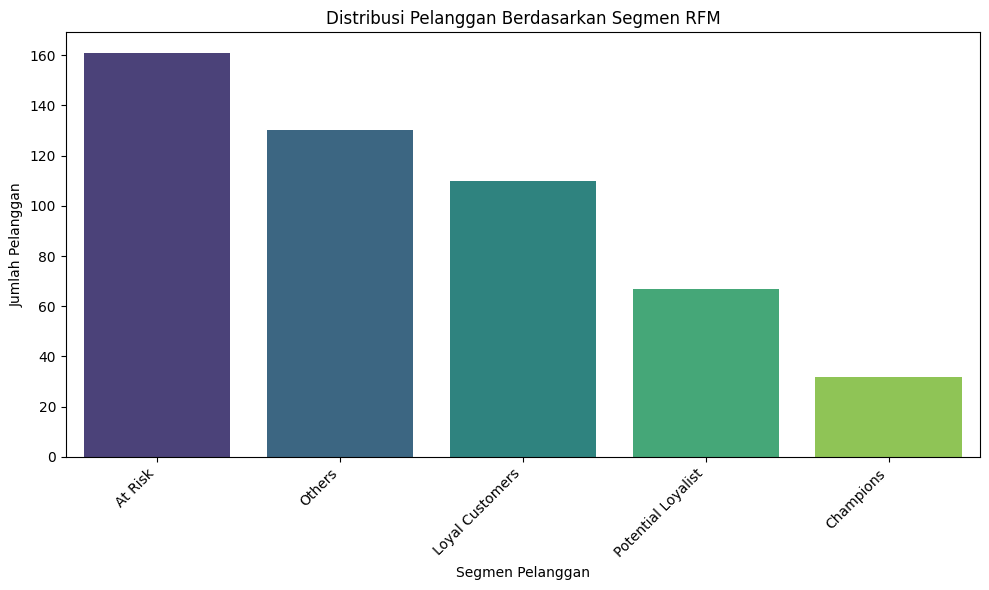

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung jumlah pelanggan per segmen
segment_counts = rfm_df['Customer_Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

# Buat bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Segment', y='Count', data=segment_counts, palette='viridis')
plt.title('Distribusi Pelanggan Berdasarkan Segmen RFM')
plt.xlabel('Segmen Pelanggan')
plt.ylabel('Jumlah Pelanggan')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()